# Task 2.1 — Dataset Selection and Setup


## Dataset Choice: Olivetti Faces (AT&T Faces)

**Source:** `sklearn.datasets.fetch_olivetti_faces`

I chose the **Olivetti Faces dataset** because it is the most natural toy analogue of the paper's original dataset (Labeled Faces in the Wild — LFW). The paper's task is face verification: given two face images, determine if they are the same person. The Olivetti dataset also contains face images with multiple images per identity, which makes it directly suitable for constructing same/different person pairs.

### Dataset Stats
- 400 grayscale images, 40 subjects × 10 images each
- Image size: 64×64 pixels → 4096 features per image
- Already normalized to [0, 1] float values

### Justification
- **Supports the same pairwise task** as the paper: same-person vs. different-person pairs
- **Sufficient size**: 400 images generate thousands of pairs (≥100 samples requirement easily met)
- **Multiple features**: 4096 features per image (>>2 required)
- **No GPU needed**: Fits entirely in RAM, SVM training finishes in seconds on a laptop
- **Well-understood benchmark**: Widely used in academic ML, so results are interpretable

### Limitations vs. Original Paper
| Property | This Work | Brunner et al. (2012) |
|---|---|---|
| Dataset | Olivetti (400 images, 40 identities) | LFW (13,000+ images, 5,749 identities) |
| Features | Raw pixel intensities | SIFT, LBP, TPLBP descriptors |
| No. of Pairs | ~10,000 | 2 million+ |
| Hardware | Laptop CPU | HPC cluster (24h training) |
| Kernel evaluated | RBF + K_DL | Custom TPLBP + K_TM^poly |

Because of the smaller dataset and simpler features, absolute accuracy numbers are not directly comparable to the paper. The goal here is to verify the **relative pattern**: that the balanced pairwise kernel outperforms the plain direct kernel.

In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Load the dataset
data = fetch_olivetti_faces(shuffle=False)
X = data.data          # shape: (400, 4096)
y = data.target        # shape: (400,) — identity labels 0..39

print(f"Images: {X.shape[0]}, Features per image: {X.shape[1]}")
print(f"Unique identities: {len(np.unique(y))}")
print(f"Images per identity: {np.bincount(y)[0]} (same for all 40)")
print(f"Pixel value range: [{X.min():.2f}, {X.max():.2f}] (already normalized)")

Images: 400, Features per image: 4096
Unique identities: 40
Images per identity: 10 (same for all 40)
Pixel value range: [0.00, 1.00] (already normalized)


**Code Explanation:** We load the Olivetti dataset using `fetch_olivetti_faces`. Each of the 400 images is a 64×64 grayscale face, already flattened to 4096 dimensions and normalized to [0,1]. The 40 identities each have exactly 10 images.

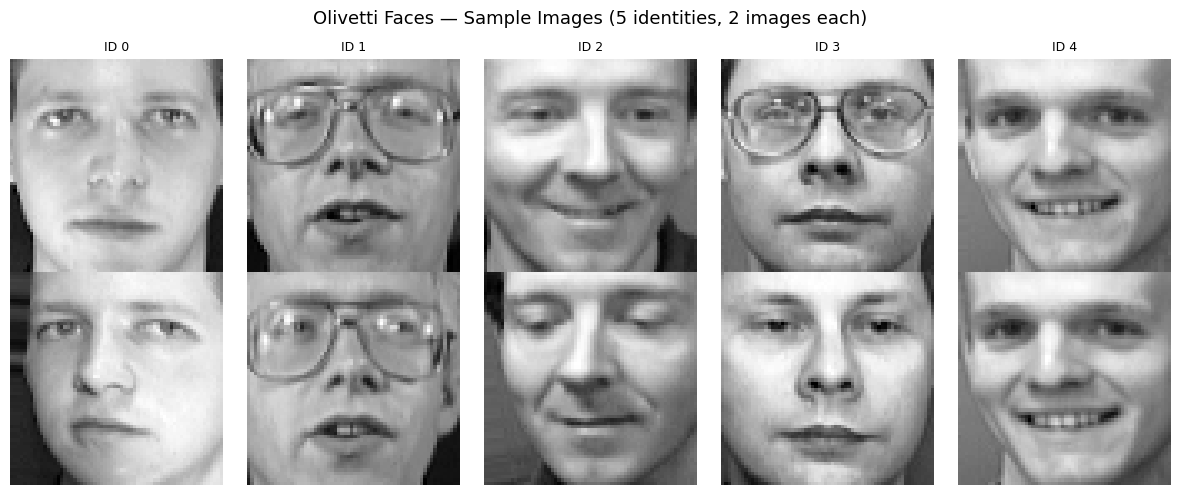

Saved: results/dataset_samples.png


In [2]:
# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Olivetti Faces — Sample Images (5 identities, 2 images each)", fontsize=13)

for i in range(5):
    idx_imgs = np.where(y == i)[0]  # 10 images for identity i
    axes[0, i].imshow(X[idx_imgs[0]].reshape(64, 64), cmap='gray')
    axes[0, i].set_title(f"ID {i}", fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(X[idx_imgs[3]].reshape(64, 64), cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("results/dataset_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/dataset_samples.png")

**Code Explanation:** We display 5 identities × 2 images each to visually confirm that the dataset has realistic within-identity variation (different poses/expressions) and clear between-identity differences.

In [3]:
# Construct pairwise dataset for binary classification
# Positive pairs: same identity; Negative pairs: different identity

def build_pairs(X, y, n_pos=1000, n_neg=1000, random_state=42):
    """
    Build same/different person pairs for pairwise SVM training.
    Returns:
        pairs_a, pairs_b: arrays of image feature vectors for each side of the pair
        labels: +1 for same identity, -1 for different identity
    """
    rng = np.random.RandomState(random_state)
    pairs_a, pairs_b, labels = [], [], []
    identities = np.unique(y)

    # Positive pairs (same identity)
    count = 0
    while count < n_pos:
        identity = rng.choice(identities)
        imgs = np.where(y == identity)[0]
        if len(imgs) < 2:
            continue
        i, j = rng.choice(imgs, size=2, replace=False)
        pairs_a.append(X[i])
        pairs_b.append(X[j])
        labels.append(1)
        count += 1

    # Negative pairs (different identities)
    count = 0
    while count < n_neg:
        id1, id2 = rng.choice(identities, size=2, replace=False)
        i = rng.choice(np.where(y == id1)[0])
        j = rng.choice(np.where(y == id2)[0])
        pairs_a.append(X[i])
        pairs_b.append(X[j])
        labels.append(-1)
        count += 1

    return (np.array(pairs_a), np.array(pairs_b), np.array(labels))


pairs_a, pairs_b, labels = build_pairs(X, y, n_pos=1000, n_neg=1000)

print(f"Total pairs: {len(labels)}")
print(f"Positive (same person): {np.sum(labels == 1)}")
print(f"Negative (different): {np.sum(labels == -1)}")
print(f"Pair feature dimension (a or b): {pairs_a.shape[1]}")

Total pairs: 2000
Positive (same person): 1000
Negative (different): 1000
Pair feature dimension (a or b): 4096


**Code Explanation — `build_pairs` function:**  
This function constructs the binary pairwise classification dataset described in Section 2 of the paper (Equation 1). For each pair $(a_i, b_i)$:
- **Same identity** → label $y_i = +1$
- **Different identity** → label $y_i = -1$

We sample 1,000 of each to keep the dataset balanced, matching the training paradigm described in Section 5.1 of the paper.